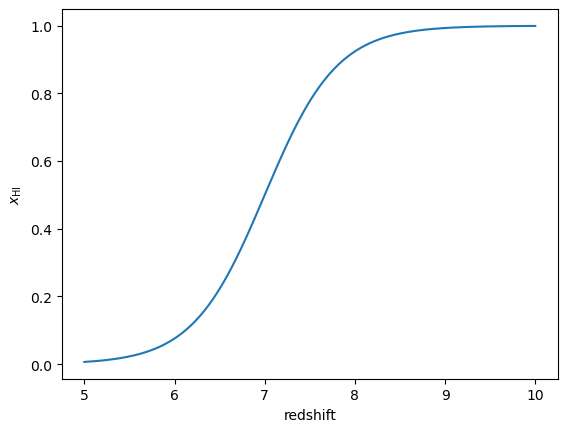

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def xHI_model1(z,z_mid,delta):
    return 0.5*(1+ np.tanh((z-z_mid)/delta))
z=np.linspace(5,10,200)
z_mid=7
delta=0.8
xHI=xHI_model1(z,z_mid,delta)
plt.plot(z,xHI)
plt.xlabel('redshift')
plt.ylabel('$x_{\mathrm{HI}}$')
plt.show()

[output] Output to be read-from/written-into folder 'chains', with prefix 'asym_v2'
[output] Found existing info files with the requested output prefix: 'chains/asym_v2'
[output] Will delete previous products ('force' was requested).
[reion_like] Initialized external likelihood.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: z_mid:7.2, delta:1
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {reion_like: 26500.0}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling! (NB: no accepted step will be saved until 5000 burn-in samples have been obtained)
[mcmc] Progress @ 2026-04-29 19:41:18 : 1 steps taken -- still burning in, 5001 accepted steps left.
[mcmc] Finished burn-in phase: discarded 5000 accepted steps.
[mcmc] *WARNING* Proposal has been rejected 80 times
[mcmc] Learn + convergence test @

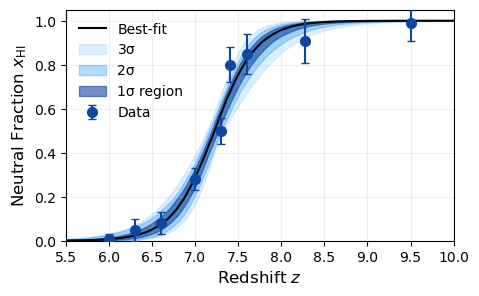

In [2]:
from getdist import plots
from getdist.mcsamples import loadMCSamples
import matplotlib.pyplot as plt
import numpy as np
z_array = np.array([6.6, 7, 7.3, 7.4, 7.6, 8.28,9.5])
xHI_data = np.array([0.08, 0.28, 0.5, 0.80, 0.85, 0.91,0.99])
z_LAE = np.array([6.0, 6.3])

xHI_LAE = np.array([0.01, 0.05])
sigma_data= np.array([0.05, 0.05, 0.06, 0.08, 0.09, 0.10,0.08])
sigma_data_LAE = np.array([0.02, 0.05])
z_all = np.concatenate([z_array, z_LAE])
xHI_all = np.concatenate([xHI_data, xHI_LAE])
sigma_all = np.concatenate([sigma_data,sigma_data_LAE])
import numpy as np
z_smooth=np.linspace(5,10,200)
def xHI_model(z, z_mid, delta):
    return 1 / (1 + np.exp(-(z - z_mid)/delta))

def loglike(z_mid, delta):
    model = xHI_model(z_all, z_mid, delta)
    chi2 = np.sum(((xHI_all - model)/sigma_all)**2)
    return -0.5 * chi2
from cobaya.run import run

info = {
    "params": {
        "z_mid": {
            "prior": {"min": 6.5, "max": 10},
            "ref": 7.2,
            "proposal": 0.1
        },
        "delta": {
            "prior": {"min": 0.1, "max": 3.0},
            "ref": 1.0,
            "proposal": 0.1
        },
    },

    "likelihood": {
        "reion_like": loglike
    },

    "sampler": {
        "mcmc": {
            "max_samples": 200000,
            "Rminus1_stop": 0.01,
            "oversample_power":0,
            "burn_in":5000
        }
    },
    "output": "chains/asym_v2",
    "force": True
}

updated_info, sampler = run(info)
z_plot=np.linspace(5,10,200)
samples = loadMCSamples("chains/asym_v2")
p=samples.getParams()
zmid = p.z_mid
delta1 = p.delta
p=samples.getParams()

z_smooth = np.linspace(5, 10, 200)
num_samples=len(p.z_mid)
models = []
for i in range(0,num_samples, 10):
    m=xHI_model(z_smooth,p.z_mid[i],p.delta[i])
    models.append(m)

models = np.array(models)

xHI_median = np.median(models, axis=0)
xHI_16 = np.percentile(models, 16, axis=0)
xHI_84 = np.percentile(models, 84, axis=0)
# 2σ
xHI_2p5  = np.percentile(models, 2.5, axis=0)
xHI_97p5 = np.percentile(models, 97.5, axis=0)

# 3σ
xHI_0p15  = np.percentile(models, 0.15, axis=0)
xHI_99p85 = np.percentile(models, 99.85, axis=0)
plt.figure(figsize=(5,3))

# Data
plt.errorbar(z_all, xHI_all, yerr=sigma_all,
             fmt='o', color='#0D47A1',
             ecolor='#0D47A1',
             markersize=7,
             capsize=3,
             zorder=11,label='Data')

# Model
plt.plot(z_smooth, xHI_median, color='black', linewidth=1.5, zorder=5,label='Best-fit')
plt.fill_between(z_smooth, xHI_0p15, xHI_99p85,
                 color='#90CAF9', alpha=0.3, label='3σ')

# 2σ
plt.fill_between(z_smooth, xHI_2p5, xHI_97p5,
                 color='#42A5F5', alpha=0.4, label='2σ')

# 1σ (darkest)
plt.fill_between(z_smooth, xHI_16, xHI_84,
                 color='#0D47A1', alpha=0.6, label='1σ region')
plt.xlim(5.5, 10)
plt.ylim(0, 1.05)
plt.xlabel('Redshift $z$', fontsize=12)
plt.ylabel('Neutral Fraction $x_{\\mathrm{HI}}$', fontsize=12)
plt.legend(frameon=False, fontsize=10)
plt.grid(alpha=0.2)

plt.show()


In [3]:
zmid = p.z_mid
delta1 = p.delta

# z_mid
zmid_median = np.percentile(zmid, 50)
zmid_low = np.percentile(zmid, 16)
zmid_high = np.percentile(zmid, 84)

# delta
delta_median = np.percentile(delta1, 50)
delta_low = np.percentile(delta1, 16)
delta_high = np.percentile(delta1, 84)

print(f"z_mid = {zmid_median:.3f} +{zmid_high - zmid_median:.3f} -{zmid_median - zmid_low:.3f}")
print(f"delta = {delta_median:.3f} +{delta_high - delta_median:.3f} -{delta_median - delta_low:.3f}")

z_mid = 7.227 +0.044 -0.040
delta = 0.253 +0.045 -0.042


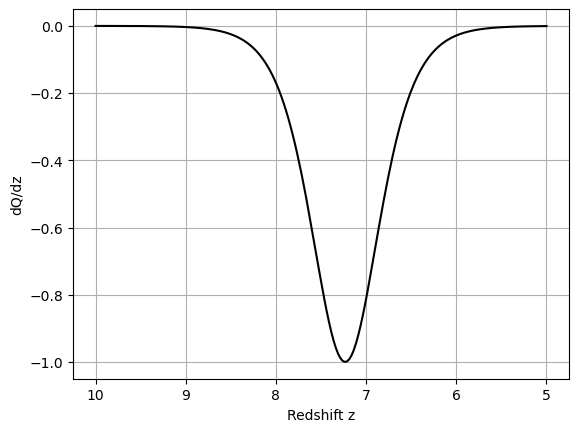

In [3]:
import numpy as np
import matplotlib.pyplot as plt

z_mid = 7.232
delta = 0.250

z_plot = np.linspace(5, 10, 200)

xHI = 1 / (1 + np.exp(-(z_plot - z_mid)/delta))
Q = 1-xHI
# Analytical derivative
dq = -(1/delta) * Q * (1 - Q)

# Plot
plt.plot(z_plot, dq, color='black')
plt.xlabel("Redshift z")
plt.ylabel("dQ/dz")
plt.gca().invert_xaxis()
plt.grid()
plt.show()

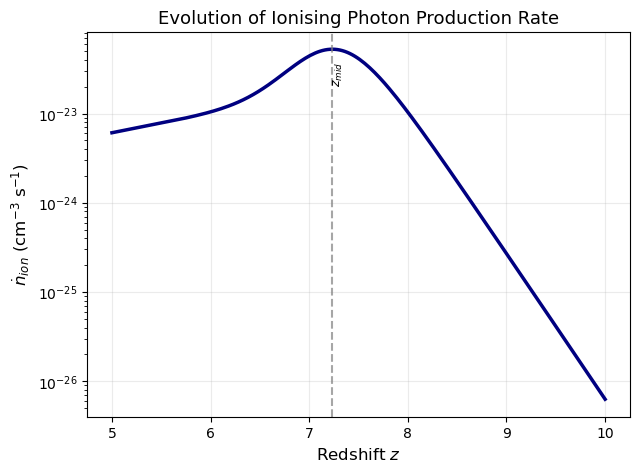

In [16]:
nH_0 = 1.9e-7  
H0 =  68* 1e5 / 3.086e24  
Omega_m = 0.3
Omega_lambda = 0.7

def H(z):
    return H0 * np.sqrt(Omega_m * (1+z)**3 + Omega_lambda)
alpha_B = 2.6e-13   
C=3
def t_rec(z):
    return 1 / (alpha_B * C * nH_0 * (1+z)**3)
dQ_dt = -(1+z_plot) * H(z_plot) * dq

# recombination time
trec = t_rec(z_plot)
ndot_ion1=nH_0*(dQ_dt+Q/trec)

plt.figure(figsize=(7,5))
plt.plot(z_plot, ndot_ion1,color='navy',linewidth=2.5)
plt.axvline(7.228, linestyle='--', color='gray', alpha=0.7)
plt.text(7.228, 2e-23, r'$z_{mid}$', rotation=90, va='bottom', fontsize=9)


plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"$\dot{n}_{ion}$ (cm$^{-3}$ s$^{-1}$)", fontsize=12)
plt.title("Evolution of Ionising Photon Production Rate", fontsize=13)
plt.yscale('log')


plt.grid(alpha=0.25)

plt.show()


Reionization ends at z ≈ 6.070000000000084


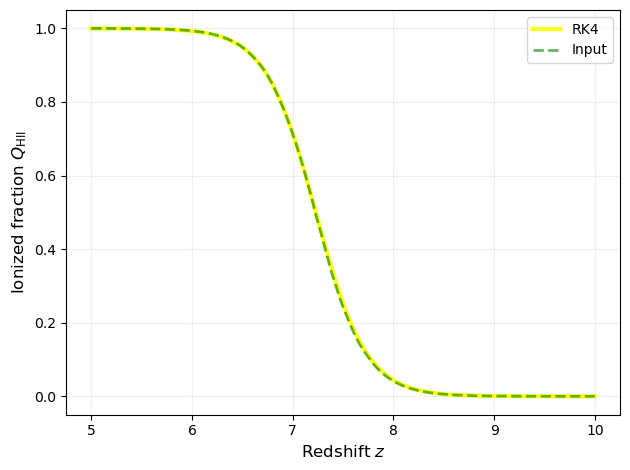

In [61]:
from scipy.interpolate import interp1d
log_ndot=np.log10(ndot_ion)
ndot_func = interp1d(z_plot, log_ndot, kind='linear', fill_value="extrapolate")
def ndot_interp(z):
    return 10**ndot_func(z)
def dQ_dz_reion(z, Q):
    
    ndot =ndot_interp(z)
    term = (ndot / nH_0) - Q / t_rec(z)
    return - term / ((1+z) * H(z))
z_start = 10
z_end = 5
h = -0.01   # negative step

z_vals = []
Q_vals = []

z = z_start
Q = 0.0   # initial condition (neutral universe)

while z >= z_end:
    z_vals.append(z)
    Q_vals.append(Q)
    
    k1 = dQ_dz_reion(z, Q)
    k2 = dQ_dz_reion(z + h/2, Q + h*k1/2)
    k3 = dQ_dz_reion(z + h/2, Q + h*k2/2)
    k4 = dQ_dz_reion(z + h, Q + h*k3)
    
    Q = Q + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    z = z + h

z_vals = np.array(z_vals)
Q_vals = np.array(Q_vals)

threshold = 0.99


idx = np.where(Q_vals >= threshold)[0][0]

z_end = z_vals[idx]
QHI=1-xHI_median
print("Reionization ends at z ≈", z_end)
import matplotlib.pyplot as plt

plt.plot(z_vals, Q_vals, color='yellow', lw=3, alpha=0.9, label="RK4")
plt.plot(z_plot, QHI, color='green', lw=2, linestyle='--', alpha=0.6, label="Input")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Ionized fraction $Q_{\mathrm{HII}}$", fontsize=12)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

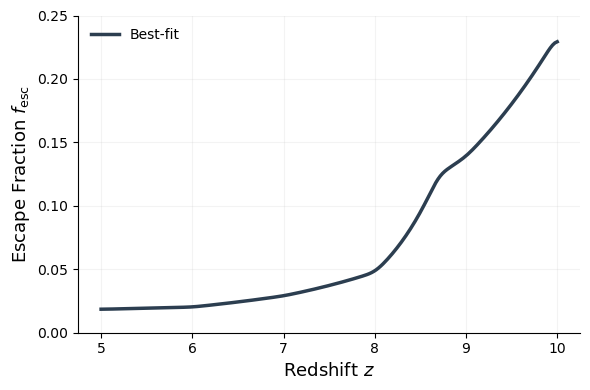

0.22930880664639353
0.018530746187457543


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
pc=3.086e18
h=6.626e-27
beta=1.5
a=1.21
b=1.02
c=2.34
d=2.89
R=0.2
cm_per_Mpc = 3.07e24
z=np.array([5,6,7,8,8.7,9,10.5,12,14.7])
phi_star=np.array([5.61e-4,5.16e-4,1.81e-4,8.7e-5,1.36e-5,1.21e-5,7.25e-6,5.74e-6,2.45e-6])
m_star=np.array([-21.3,-21.1,-21,-20.9,-20.9,-20.8,-20.5,-20.5,-20.2])
alpha=np.array([-1.78,-1.87,-2.05,-2.12,-2.26,-2.28,-2.3,-2.32,-2.35])
M = np.linspace(-23, -10, 1000)
z_smooth=np.linspace(5,10,200)
ndot_gamma1 = []

for i in range(len(z)):
    z1 = z[i]
    A = (a + b*z1)/(1 + (z1/c)**d)
    phi_star1 = phi_star[i]
    m_star1 = m_star[i]
    alpha1 = alpha[i]
    phi = 0.4*np.log(10)*phi_star1*10**(-0.4*(M-m_star1)*(alpha1+1))*np.exp(-10**(-0.4*(M-m_star1)))
    L = 4*np.pi*(10*pc)**2 * 10**(-0.4*(M + 48.6))
    rho_uv = np.trapz(phi*L, M)
    rho_uv_1500 = rho_uv * 10**(0.4*A)
    rho_uv_912 = R * rho_uv_1500
    ndot_gamma = rho_uv_912 / (h * beta)
    ndot_ion=ndot_gamma
    ndot_ion1=ndot_ion/cm_per_Mpc**3
    ndot_gamma1.append(ndot_ion1)
z_bins=np.array([5,6,7,8,8.7,9,10.5,12,14.7])
ndot_bins = np.array(ndot_gamma1)
ndot_log=np.log10(ndot_bins)
ndot_func = interp1d(z_bins, ndot_log, kind='linear', fill_value=(ndot_log[0], ndot_log[-1]))

def ndot_gamma_func(z):
    return 10**ndot_func(z)
ndot_gamma=ndot_gamma_func(z_plot)
cm_to_Mpc = 3.086e24
ndot_ion_Mpc = ndot_ion / (cm_to_Mpc**3)
fesc=ndot_ion_Mpc/ndot_gamma
fesc_smooth = gaussian_filter1d(fesc, sigma=2.5)
plt.figure(figsize=(6,4))



plt.plot(z_plot, fesc_smooth, color='#2c3e50', lw=2.5, label='Best-fit')


plt.xlabel(r'Redshift $z$', fontsize=13)
plt.ylabel(r'Escape Fraction $f_{\mathrm{esc}}$', fontsize=13)
plt.xticks(np.arange(5, 11, 1))
plt.ylim(0, 0.25)
plt.grid(alpha=0.15)
plt.legend(loc='upper left', frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

plt.show()
print(max(fesc_smooth))
print(min(fesc_smooth))





